In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import yfinance as yf

# Companies to compare
tickers = {
    "NVDA": "Nvidia",
    "AMD": "AMD",
    "INTC": "Intel",
    "TSM": "TSMC",
    "QCOM": "Qualcomm",
    "AVGO": "Broadcom",
    "ASML": "ASML"
}

# Daily price history
price_frames = []

for ticker, name in tickers.items():
    price_history = yf.Ticker(ticker).history(interval="1mo", period="2y")
    price_history["Company"] = name
    price_frames.append(price_history)

df_prices = pd.concat(price_frames).reset_index()
df_prices.to_csv("Data/gpu_companies_price_history.csv", index=False)

df_prices = df_prices.filter(["Date", "Company", "Close"])

# Quarterly income statement data
statement_frames = []

for ticker, name in tickers.items():
    financial_stm = yf.Ticker(ticker).quarterly_income_stmt.T
    financial_stm["Company"] = name
    statement_frames.append(financial_stm)

df_statements = pd.concat(statement_frames).reset_index()
df_statements.rename(columns={"index":"Date"}, inplace=True)
df_statements.to_csv("Data/gpu_companies_quarterly_financial_statments.csv", index=False)

#Check Company Info Like Currencies Used To Report
for ticker in tickers:
    print(ticker, yf.Ticker(ticker).info.get("financialCurrency"))

# Rate Conversions For TSMC and ASML
TWD_TO_USD = 0.032
EUR_TO_USD = 1.16

columns_to_convert = ["Total Revenue", "Net Income", "Gross Profit",
                      "Operating Income", "Diluted EPS"]

df_statements.loc[df_statements["Company"] == "TSMC", columns_to_convert] *= TWD_TO_USD
df_statements.loc[df_statements["Company"] == "ASML", columns_to_convert] *= EUR_TO_USD

NVDA USD
AMD USD
INTC USD
TSM TWD
QCOM USD
AVGO USD
ASML EUR


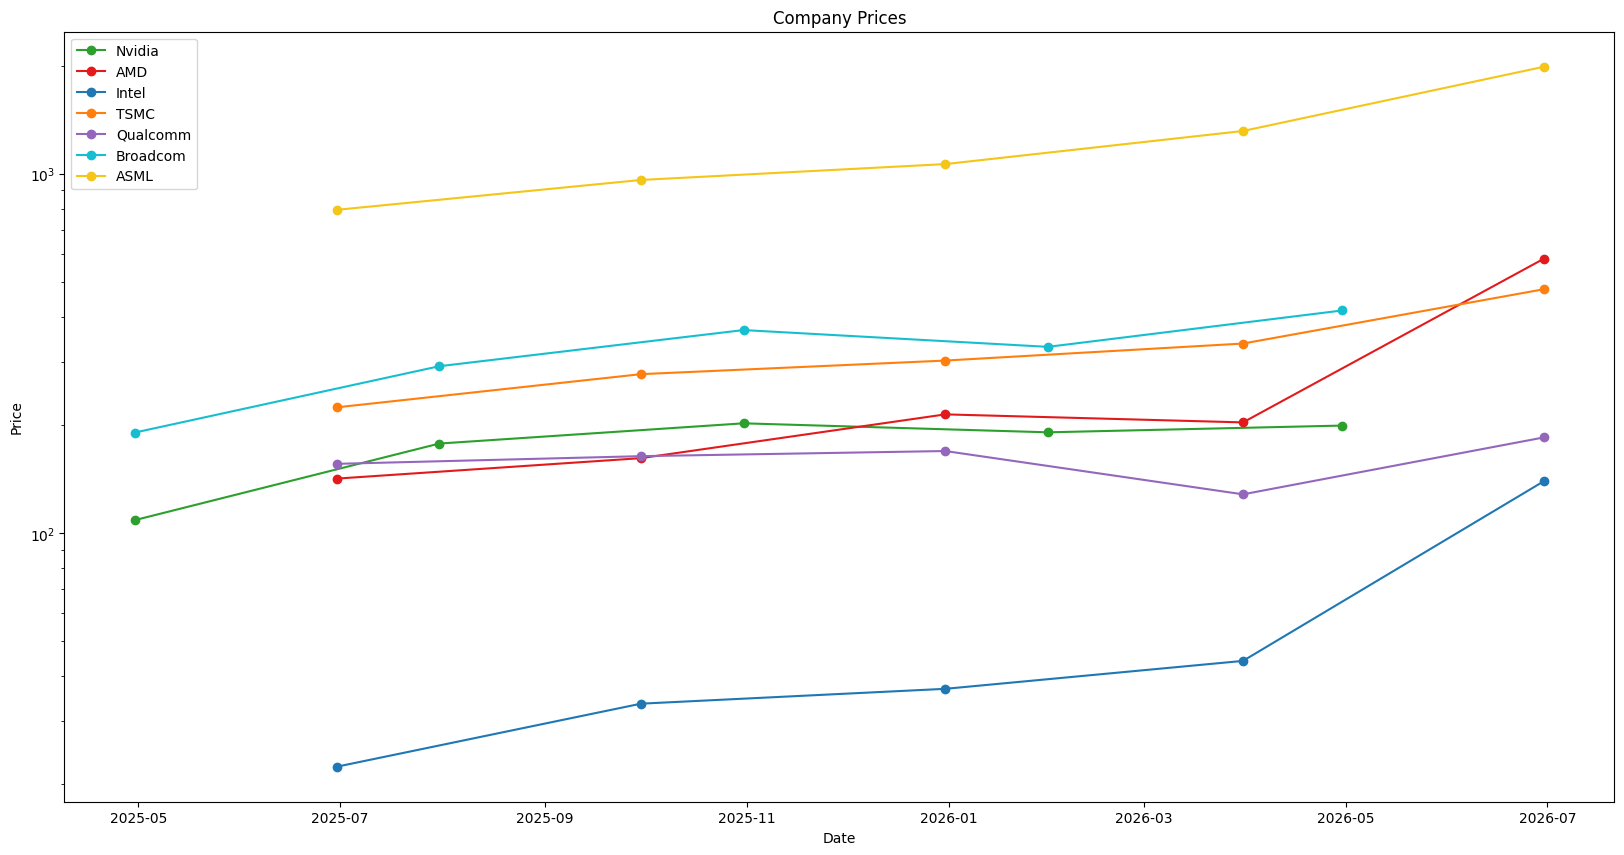

In [3]:
!pip install -U kaleido==0.2.1

#Data Cleaning, Adding, Format & Merge
df_prices.rename(columns={"Close": "Price"}, inplace=True)

df_prices.Date = pd.to_datetime(df_prices.Date, format="%Y/%m/%d").dt.tz_localize(None)
df_sorted_price = df_prices.sort_values(by="Date")

df_statements = df_statements.filter(["Date", "Company",
                                      "Total Revenue", "Gross Profit",
                                      "Operating Income", "Net Income",
                                      "Diluted EPS",
                                      "Diluted Average Shares"])

df_statements.Date = pd.to_datetime(df_statements.Date, format="%Y/%m/%d")
df_sorted_statement = df_statements.sort_values(by="Date")

df_data = pd.merge_asof(df_sorted_statement,
                        df_sorted_price,
                        on="Date",
                        by="Company",
                        direction="backward")
df_data.dropna(inplace=True)

df_data["Market Cap"] = df_data["Price"] * df_data["Diluted Average Shares"]
df_data["P/E_ratio"] = df_data["Price"] / df_data["Diluted EPS"]
df_data["Revenue Growth"] = df_data.groupby("Company")["Total Revenue"].pct_change()

company_colors = {
    "Nvidia": "#2CA02C",     # green
    "AMD": "#E31A1C",        # red
    "Intel": "#1F77B4",      # blue
    "TSMC": "#FF7F0E",       # orange
    "Qualcomm": "#9467BD",   # purple
    "Broadcom": "#17BECF",   # teal/cyan
    "ASML": "#F5C518"        # yellow/gold
    }

company_order = list(tickers.values())

#Total Revenue Bar Chart
company_group = df_data.groupby(by="Company", as_index=False).agg("Total Revenue").sum()
revenue_bar_chart = px.bar(company_group,
                           "Company",
                           "Total Revenue",
                           title="Company Total Revenues",
                           color="Company",
                           color_discrete_map=company_colors,
                           category_orders={"Company": company_order})
revenue_bar_chart.write_image("Graphs/total_revenue_bar.png", scale=2)
revenue_bar_chart.show()

#Market Share Pie Chart
company_quarter_group = df_data
market_share_chart = px.pie(company_quarter_group,
                            "Company",
                            "Total Revenue",
                            title="Company Market Share",
                            color="Company",
                            color_discrete_map=company_colors,
                            category_orders={"Company": company_order})
market_share_chart.write_image("Graphs/market_share_pie.png", scale=2)
market_share_chart.show()

#Quarterly Revenue Bar Chart
revenue_quarter_bar_chart = px.bar(company_quarter_group,
                           "Date",
                           "Total Revenue",
                           title="Company Quarterly Revenues",
                           color="Company",
                           color_discrete_map=company_colors,
                           category_orders={"Company": company_order},
                           barmode="group")
revenue_quarter_bar_chart.write_image("Graphs/quarterly_revenue_bar.png", scale=2)
revenue_quarter_bar_chart.show()

#Quarterly P/E vs Revenue Growth, Sized by Market Cap Bubble Chart
company_bubble_chart = px.scatter(company_quarter_group,
                              "P/E_ratio",
                              "Revenue Growth",
                              title="Quarterly P/E vs Revenue Growth, Sized by Market Cap",
                              color="Company",
                              color_discrete_map=company_colors,
                              category_orders={"Company": company_order},
                              size="Market Cap",
                              hover_data="Date")
company_bubble_chart.write_image("Graphs/pe_vs_growth_bubble.png", scale=2)
company_bubble_chart.show()

#Price Distribution Box Chart
price_dist_chart = px.box(company_quarter_group,
                          "Company",
                          "Price",
                          title="Price Distribution",
                          color="Company",
                          color_discrete_map=company_colors,
                          category_orders={"Company": company_order})
price_dist_chart.update_layout(yaxis=dict(type="log",
                                          tickformat=",.0f",
                                          dtick=0.33))
price_dist_chart.write_image("Graphs/price_distribution_box.png", scale=2)
price_dist_chart.show()

#Price Line Chart
plt.figure(figsize=[20, 10])
plt.title("Company Prices")

for company in company_order:
    x = company_quarter_group.Date[company_quarter_group["Company"] == company]
    y = company_quarter_group.Price[company_quarter_group["Company"] == company]
    plt.plot(x, y, marker="o", label=company, color=company_colors[company])

plt.yscale("log")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("Graphs/price_line_chart.png", dpi=200, bbox_inches="tight")
plt.show()

#Test
# df_data.head()

NVDA USD
AMD USD
INTC USD
TSM TWD
QCOM USD
AVGO USD
ASML EUR


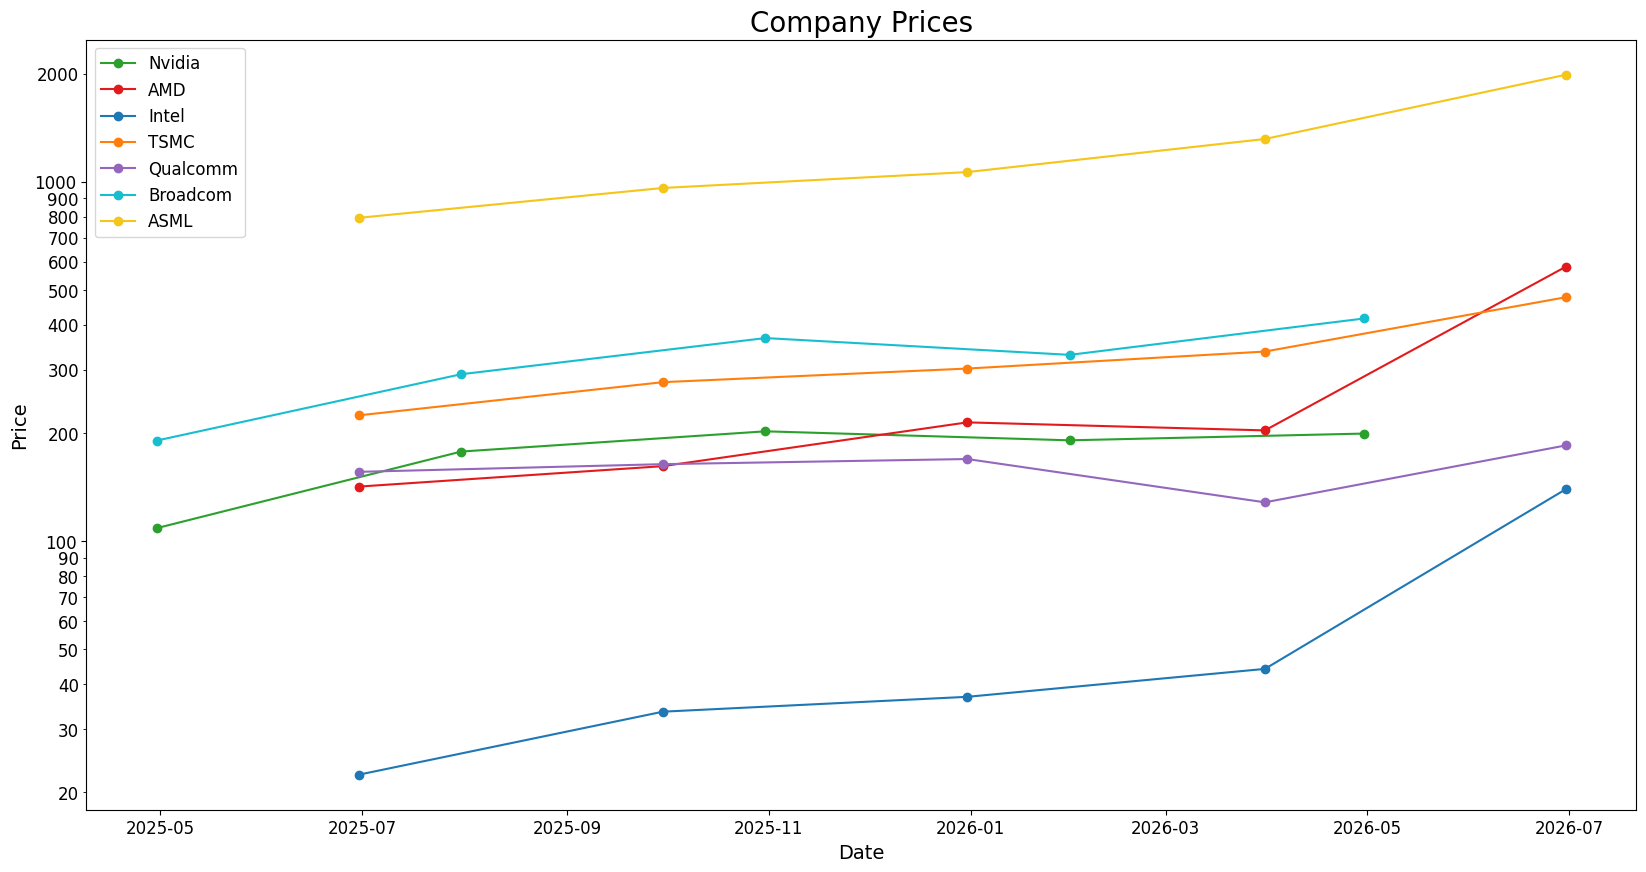

In [5]:
!pip install -U kaleido==0.2.1

import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import yfinance as yf

# Companies to compare
tickers = {
    "NVDA": "Nvidia",
    "AMD": "AMD",
    "INTC": "Intel",
    "TSM": "TSMC",
    "QCOM": "Qualcomm",
    "AVGO": "Broadcom",
    "ASML": "ASML"
}

# Daily price history
price_frames = []

for ticker, name in tickers.items():
    price_history = yf.Ticker(ticker).history(interval="1mo", period="2y")
    price_history["Company"] = name
    price_frames.append(price_history)

df_prices = pd.concat(price_frames).reset_index()
df_prices.to_csv("Data/gpu_companies_price_history.csv", index=False)

df_prices = df_prices.filter(["Date", "Company", "Close"])

# Quarterly income statement data
statement_frames = []

for ticker, name in tickers.items():
    financial_stm = yf.Ticker(ticker).quarterly_income_stmt.T
    financial_stm["Company"] = name
    statement_frames.append(financial_stm)

df_statements = pd.concat(statement_frames).reset_index()
df_statements.rename(columns={"index": "Date"}, inplace=True)
df_statements.to_csv("Data/gpu_companies_quarterly_financial_statments.csv", index=False)

# Check Company Info Like Currencies Used To Report
for ticker in tickers:
    print(ticker, yf.Ticker(ticker).info.get("financialCurrency"))

# Rate Conversions For TSMC and ASML
TWD_TO_USD = 0.032
EUR_TO_USD = 1.16

columns_to_convert = ["Total Revenue", "Net Income", "Gross Profit",
                      "Operating Income", "Diluted EPS"]

df_statements.loc[df_statements["Company"] == "TSMC", columns_to_convert] *= TWD_TO_USD
df_statements.loc[df_statements["Company"] == "ASML", columns_to_convert] *= EUR_TO_USD

# Data Cleaning, Adding, Format & Merge
df_prices.rename(columns={"Close": "Price"}, inplace=True)

df_prices.Date = pd.to_datetime(df_prices.Date, format="%Y/%m/%d").dt.tz_localize(None)
df_sorted_price = df_prices.sort_values(by="Date")

df_statements = df_statements.filter(["Date", "Company",
                                      "Total Revenue", "Gross Profit",
                                      "Operating Income", "Net Income",
                                      "Diluted EPS",
                                      "Diluted Average Shares"])

df_statements.Date = pd.to_datetime(df_statements.Date, format="%Y/%m/%d")
df_sorted_statement = df_statements.sort_values(by="Date")

df_data = pd.merge_asof(df_sorted_statement,
                        df_sorted_price,
                        on="Date",
                        by="Company",
                        direction="backward")
df_data.dropna(inplace=True)

df_data["Market Cap"] = df_data["Price"] * df_data["Diluted Average Shares"]
df_data["P/E_ratio"] = df_data["Price"] / df_data["Diluted EPS"]
df_data["Revenue Growth"] = df_data.groupby("Company")["Total Revenue"].pct_change()

company_colors = {
    "Nvidia": "#2CA02C",     # green
    "AMD": "#E31A1C",        # red
    "Intel": "#1F77B4",      # blue
    "TSMC": "#FF7F0E",       # orange
    "Qualcomm": "#9467BD",   # purple
    "Broadcom": "#17BECF",   # teal/cyan
    "ASML": "#F5C518"        # yellow/gold
    }

company_order = list(tickers.values())

# Shared font sizes so every chart (Plotly + Matplotlib) looks consistent
TITLE_SIZE = 20
AXIS_LABEL_SIZE = 14
TICK_SIZE = 12

plotly_font_layout = dict(
    title_font_size=TITLE_SIZE,
    xaxis_title_font_size=AXIS_LABEL_SIZE,
    yaxis_title_font_size=AXIS_LABEL_SIZE,
    xaxis_tickfont_size=TICK_SIZE,
    yaxis_tickfont_size=TICK_SIZE
)

plt.rcParams.update({
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": TICK_SIZE
})

#Total Revenue Bar Chart
company_group = df_data.groupby(by="Company", as_index=False).agg("Total Revenue").sum()
revenue_bar_chart = px.bar(company_group,
                           "Company",
                           "Total Revenue",
                           title="Company Total Revenues",
                           color="Company",
                           color_discrete_map=company_colors,
                           category_orders={"Company": company_order})
revenue_bar_chart.update_layout(**plotly_font_layout)
revenue_bar_chart.show()

#Market Share Pie Chart
company_quarter_group = df_data
market_share_chart = px.pie(company_quarter_group,
                            "Company",
                            "Total Revenue",
                            title="Company Market Share",
                            color="Company",
                            color_discrete_map=company_colors,
                            category_orders={"Company": company_order})
market_share_chart.update_layout(**plotly_font_layout)
market_share_chart.show()

#Quarterly Revenue Bar Chart
revenue_quarter_bar_chart = px.bar(company_quarter_group,
                           "Date",
                           "Total Revenue",
                           title="Company Quarterly Revenues",
                           color="Company",
                           color_discrete_map=company_colors,
                           category_orders={"Company": company_order},
                           barmode="group")
revenue_quarter_bar_chart.update_layout(**plotly_font_layout)
revenue_quarter_bar_chart.show()

#Quarterly P/E vs Revenue Growth, Sized by Market Cap Bubble Chart
company_bubble_chart = px.scatter(company_quarter_group,
                              "P/E_ratio",
                              "Revenue Growth",
                              title="Quarterly P/E vs Revenue Growth, Sized by Market Cap",
                              color="Company",
                              color_discrete_map=company_colors,
                              category_orders={"Company": company_order},
                              size="Market Cap",
                              hover_data="Date")
company_bubble_chart.update_layout(**plotly_font_layout)
company_bubble_chart.show()

#Price Distribution Box Chart
price_dist_chart = px.box(company_quarter_group,
                          "Company",
                          "Price",
                          title="Price Distribution",
                          color="Company",
                          color_discrete_map=company_colors,
                          category_orders={"Company": company_order})
price_dist_chart.update_layout(yaxis=dict(type="log",
                                          tickformat=",.0f",
                                          dtick=0.33))
price_dist_chart.update_layout(**plotly_font_layout)
price_dist_chart.show()

#Price Line Chart
plt.figure(figsize=[20, 10])
plt.title("Company Prices")

for company in company_order:
    x = company_quarter_group.Date[company_quarter_group["Company"] == company]
    y = company_quarter_group.Price[company_quarter_group["Company"] == company]
    plt.plot(x, y, marker="o", label=company, color=company_colors[company])

plt.yscale("log")
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(ScalarFormatter())
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

#Test
# df_data.head()

NVDA USD
AMD USD
INTC USD
TSM TWD
QCOM USD
AVGO USD
ASML EUR


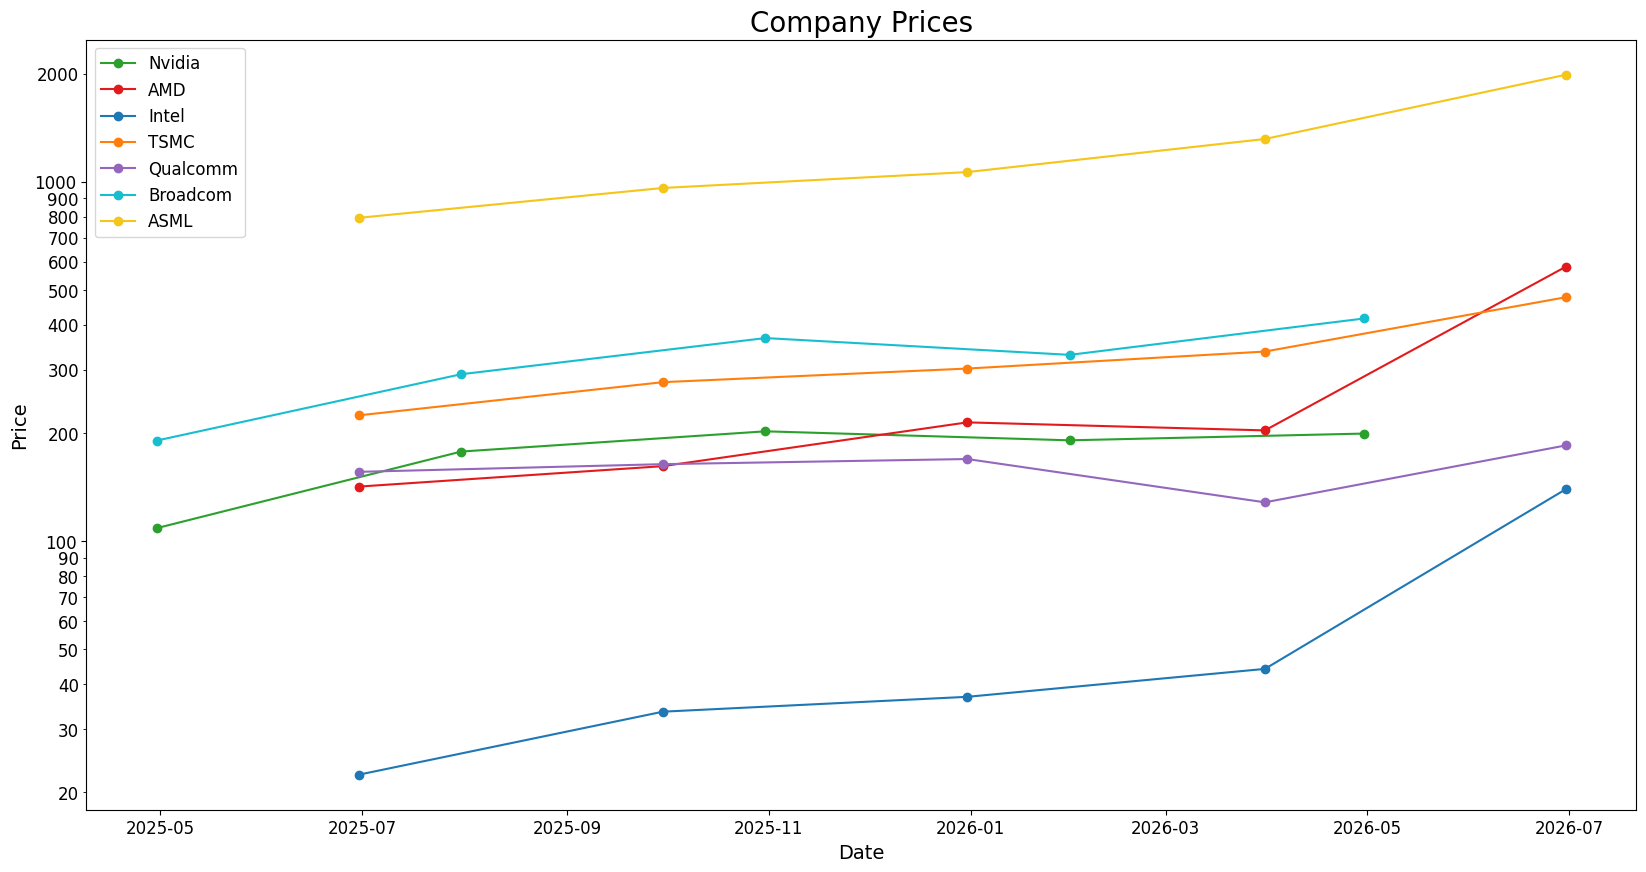

In [6]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import yfinance as yf

# Companies to compare
tickers = {
    "NVDA": "Nvidia",
    "AMD": "AMD",
    "INTC": "Intel",
    "TSM": "TSMC",
    "QCOM": "Qualcomm",
    "AVGO": "Broadcom",
    "ASML": "ASML"
}

# Daily price history
price_frames = []

for ticker, name in tickers.items():
    price_history = yf.Ticker(ticker).history(interval="1mo", period="2y")
    price_history["Company"] = name
    price_frames.append(price_history)

df_prices = pd.concat(price_frames).reset_index()
df_prices.to_csv("Data/gpu_companies_price_history.csv", index=False)

df_prices = df_prices.filter(["Date", "Company", "Close"])

# Quarterly income statement data
statement_frames = []

for ticker, name in tickers.items():
    financial_stm = yf.Ticker(ticker).quarterly_income_stmt.T
    financial_stm["Company"] = name
    statement_frames.append(financial_stm)

df_statements = pd.concat(statement_frames).reset_index()
df_statements.rename(columns={"index": "Date"}, inplace=True)
df_statements.to_csv("Data/gpu_companies_quarterly_financial_statments.csv", index=False)

# Check Company Info Like Currencies Used To Report
for ticker in tickers:
    print(ticker, yf.Ticker(ticker).info.get("financialCurrency"))

# Rate Conversions For TSMC and ASML
TWD_TO_USD = 0.032
EUR_TO_USD = 1.16

columns_to_convert = ["Total Revenue", "Net Income", "Gross Profit",
                      "Operating Income", "Diluted EPS"]

df_statements.loc[df_statements["Company"] == "TSMC", columns_to_convert] *= TWD_TO_USD
df_statements.loc[df_statements["Company"] == "ASML", columns_to_convert] *= EUR_TO_USD

# Data Cleaning, Adding, Format & Merge
df_prices.rename(columns={"Close": "Price"}, inplace=True)

df_prices.Date = pd.to_datetime(df_prices.Date, format="%Y/%m/%d").dt.tz_localize(None)
df_sorted_price = df_prices.sort_values(by="Date")

df_statements = df_statements.filter(["Date", "Company",
                                      "Total Revenue", "Gross Profit",
                                      "Operating Income", "Net Income",
                                      "Diluted EPS",
                                      "Diluted Average Shares"])

df_statements.Date = pd.to_datetime(df_statements.Date, format="%Y/%m/%d")
df_sorted_statement = df_statements.sort_values(by="Date")

df_data = pd.merge_asof(df_sorted_statement,
                        df_sorted_price,
                        on="Date",
                        by="Company",
                        direction="backward")
df_data.dropna(inplace=True)

df_data["Market Cap"] = df_data["Price"] * df_data["Diluted Average Shares"]
df_data["P/E_ratio"] = df_data["Price"] / df_data["Diluted EPS"]
df_data["Revenue Growth"] = df_data.groupby("Company")["Total Revenue"].pct_change()

company_colors = {
    "Nvidia": "#2CA02C",     # green
    "AMD": "#E31A1C",        # red
    "Intel": "#1F77B4",      # blue
    "TSMC": "#FF7F0E",       # orange
    "Qualcomm": "#9467BD",   # purple
    "Broadcom": "#17BECF",   # teal/cyan
    "ASML": "#F5C518"        # yellow/gold
    }

company_order = list(tickers.values())

# Shared font sizes so every chart (Plotly + Matplotlib) looks consistent
TITLE_SIZE = 20
AXIS_LABEL_SIZE = 14
TICK_SIZE = 12

plotly_font_layout = dict(
    title_font_size=TITLE_SIZE,
    xaxis_title_font_size=AXIS_LABEL_SIZE,
    yaxis_title_font_size=AXIS_LABEL_SIZE,
    xaxis_tickfont_size=TICK_SIZE,
    yaxis_tickfont_size=TICK_SIZE
)

plt.rcParams.update({
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": TICK_SIZE
})

#Total Revenue Bar Chart
company_group = df_data.groupby(by="Company", as_index=False).agg("Total Revenue").sum()
revenue_bar_chart = px.bar(company_group,
                           "Company",
                           "Total Revenue",
                           title="Company Total Revenues",
                           color="Company",
                           color_discrete_map=company_colors,
                           category_orders={"Company": company_order})
revenue_bar_chart.update_layout(**plotly_font_layout)
revenue_bar_chart.write_image("Graphs/total_revenue_bar.png", scale=2)
revenue_bar_chart.show()

#Market Share Pie Chart
company_quarter_group = df_data
market_share_chart = px.pie(company_quarter_group,
                            "Company",
                            "Total Revenue",
                            title="Company Market Share",
                            color="Company",
                            color_discrete_map=company_colors,
                            category_orders={"Company": company_order})
market_share_chart.update_layout(**plotly_font_layout)
market_share_chart.write_image("Graphs/market_share_pie.png", scale=2)
market_share_chart.show()

#Quarterly Revenue Bar Chart
revenue_quarter_bar_chart = px.bar(company_quarter_group,
                           "Date",
                           "Total Revenue",
                           title="Company Quarterly Revenues",
                           color="Company",
                           color_discrete_map=company_colors,
                           category_orders={"Company": company_order},
                           barmode="group")
revenue_quarter_bar_chart.update_layout(**plotly_font_layout)
revenue_quarter_bar_chart.write_image("Graphs/quarterly_revenue_bar.png", scale=2)
revenue_quarter_bar_chart.show()

#Quarterly P/E vs Revenue Growth, Sized by Market Cap Bubble Chart
company_bubble_chart = px.scatter(company_quarter_group,
                              "P/E_ratio",
                              "Revenue Growth",
                              title="Quarterly P/E vs Revenue Growth, Sized by Market Cap",
                              color="Company",
                              color_discrete_map=company_colors,
                              category_orders={"Company": company_order},
                              size="Market Cap",
                              hover_data="Date")
company_bubble_chart.update_layout(**plotly_font_layout)
company_bubble_chart.write_image("Graphs/pe_vs_growth_bubble.png", scale=2)
company_bubble_chart.show()

#Price Distribution Box Chart
price_dist_chart = px.box(company_quarter_group,
                          "Company",
                          "Price",
                          title="Price Distribution",
                          color="Company",
                          color_discrete_map=company_colors,
                          category_orders={"Company": company_order})
price_dist_chart.update_layout(yaxis=dict(type="log",
                                          tickformat=",.0f",
                                          dtick=0.33))
price_dist_chart.update_layout(**plotly_font_layout)
price_dist_chart.write_image("Graphs/price_distribution_box.png", scale=2)
price_dist_chart.show()

#Price Line Chart
plt.figure(figsize=[20, 10])
plt.title("Company Prices")

for company in company_order:
    x = company_quarter_group.Date[company_quarter_group["Company"] == company]
    y = company_quarter_group.Price[company_quarter_group["Company"] == company]
    plt.plot(x, y, marker="o", label=company, color=company_colors[company])

plt.yscale("log")
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(ScalarFormatter())
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("Graphs/price_line_chart.png", dpi=200, bbox_inches="tight")
plt.show()

#Test
# df_data.head()